# AQI Predictor - Islamabad

End-to-end air quality (PM2.5 / AQI) forecasting for the next three days.

**Pipeline overview**
1. Fetch two years of hourly air-quality and weather data (Open-Meteo, no API key required)
2. Convert PM2.5 concentrations to the US EPA Air Quality Index
3. Engineer time, lag, rolling, wind, and interaction features
4. Train multi-output models (XGBoost, LightGBM, Random Forest) for the 24h / 48h / 72h horizons
5. Evaluate with MAE, RMSE, and R-squared
6. Explain feature importance with SHAP
7. Produce a three-day forecast with categorical alerts
8. Save the trained model for the dashboard

**Requirements:** an active internet connection (Kaggle: Settings -> Internet -> ON). No API key is needed.


## 0. Setup

In [5]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, timedelta

from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Location and configuration
CITY_NAME = "Islamabad"
LAT, LON  = 33.6844, 73.0479
DAYS_BACK = 730           # two years of history (reduce to 365 if fetching is slow)

print("Setup complete. No API key required.")

Setup complete. No API key required.


## 1. Data Acquisition

Hourly air-quality and weather data are fetched separately from Open-Meteo and merged on the timestamp. Wind direction is included so that wind can later be decomposed into vector components.

In [6]:
# Open-Meteo archive data lags by a few days, so the window ends five days before today.
end_date   = date.today() - timedelta(days=5)
start_date = end_date - timedelta(days=DAYS_BACK)
print("Date range:", start_date, "to", end_date)

# Air-quality data
aq = requests.get(
    "https://air-quality-api.open-meteo.com/v1/air-quality",
    params={
        "latitude": LAT, "longitude": LON,
        "hourly": "pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone",
        "start_date": str(start_date), "end_date": str(end_date), "timezone": "auto",
    }, timeout=90,
).json()
df_aq = pd.DataFrame(aq["hourly"])

# Weather data (includes wind direction for vector features)
wx = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude": LAT, "longitude": LON,
        "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,"
                  "wind_direction_10m,precipitation,surface_pressure",
        "start_date": str(start_date), "end_date": str(end_date), "timezone": "auto",
    }, timeout=90,
).json()
df_wx = pd.DataFrame(wx["hourly"])

# Merge on the shared timestamp
df = pd.merge(df_aq, df_wx, on="time", how="inner")
df["datetime"] = pd.to_datetime(df["time"])
df = df.drop(columns=["time"]).sort_values("datetime").reset_index(drop=True)

# Drop any columns that are entirely empty for this location, then rows missing PM2.5
df = df.drop(columns=[c for c in df.columns if df[c].isna().all()])
df = df.dropna(subset=["pm2_5"]).reset_index(drop=True)

print("Merged dataset shape:", df.shape)
df.head()

Date range: 2024-06-02 to 2026-06-02
Merged dataset shape: (17544, 13)


,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,precipitation,surface_pressure,datetime
0,22.5,33.4,831.0,56.2,5.0,33.0,26.1,24,8.1,21,0.0,943.2,2024-06-02 00:00:00
1,19.3,28.8,732.0,44.9,4.0,38.0,27.8,19,0.5,315,0.0,943.5,2024-06-02 01:00:00
2,16.1,24.2,627.0,34.2,3.2,44.0,24.8,24,5.1,321,0.0,943.2,2024-06-02 02:00:00
3,13.1,19.8,519.0,25.9,2.7,46.0,26.1,21,5.8,353,0.0,943.7,2024-06-02 03:00:00
4,10.8,16.4,403.0,18.2,2.3,50.0,27.1,19,5.4,4,0.0,944.4,2024-06-02 04:00:00


## 2. PM2.5 to AQI Conversion

The US EPA Air Quality Index is a piecewise-linear function of pollutant concentration. The function below maps a PM2.5 concentration (in micrograms per cubic metre) to an AQI value and a descriptive category.

In [7]:
def calculate_aqi(pm25):
    """Convert a PM2.5 concentration to the US EPA Air Quality Index."""
    if pm25 is None or pm25 < 0:
        return 0
    breakpoints = [
        (0.0, 12.0, 0, 50), (12.1, 35.4, 51, 100), (35.5, 55.4, 101, 150),
        (55.5, 150.4, 151, 200), (150.5, 250.4, 201, 300),
        (250.5, 350.4, 301, 400), (350.5, 500.4, 401, 500),
    ]
    for c_low, c_high, i_low, i_high in breakpoints:
        if pm25 <= c_high:
            return round((i_high - i_low) / (c_high - c_low) * (pm25 - c_low) + i_low)
    return 500


def aqi_category(aqi):
    """Return the descriptive category for an AQI value."""
    if aqi <= 50:  return "Good"
    if aqi <= 100: return "Moderate"
    if aqi <= 150: return "Unhealthy for Sensitive Groups"
    if aqi <= 200: return "Unhealthy"
    if aqi <= 300: return "Very Unhealthy"
    return "Hazardous"


df["aqi"] = df["pm2_5"].apply(calculate_aqi)
df["aqi_category"] = df["aqi"].apply(aqi_category)
print(df["aqi_category"].value_counts())

aqi_category
Moderate                          8760
Unhealthy for Sensitive Groups    4825
Unhealthy                         3217
Good                               737
Very Unhealthy                       5
Name: count, dtype: int64


## 3. Feature Engineering

The following feature groups are created:

- **Log transform** of PM2.5 to stabilise the effect of extreme spikes
- **Lag features**: PM2.5 at 1 to 48 hours in the past
- **Rolling statistics**: mean and standard deviation over several windows
- **Pollutant lags** for PM10, NO2, and CO
- **Wind vectors** derived from speed and direction
- **Cyclical encodings** of hour and month
- **Interaction features**: a stagnation index and weather tendency

The prediction targets are the raw PM2.5 values 24, 48, and 72 hours into the future.

In [8]:
# Log transform stabilises variance against pollution spikes
df["pm25_log"] = np.log1p(df["pm2_5"])

# Lag features on log-PM2.5
for lag in [1, 2, 3, 6, 12, 24, 48]:
    df[f"pm25_lag_{lag}h"] = df["pm25_log"].shift(lag)

# Rolling mean and standard deviation
for window in [3, 6, 12, 24]:
    df[f"pm25_roll_mean_{window}h"] = df["pm25_log"].rolling(window).mean()
    df[f"pm25_roll_std_{window}h"]  = df["pm25_log"].rolling(window).std()

# Lags for other pollutants
for col in ["pm10", "nitrogen_dioxide", "carbon_monoxide"]:
    df[f"{col}_lag_1h"] = df[col].shift(1)
    df[f"{col}_lag_6h"] = df[col].shift(6)

# Wind vector components (more informative than raw degrees)
df["wind_x"] = df["wind_speed_10m"] * np.cos(np.deg2rad(df["wind_direction_10m"]))
df["wind_y"] = df["wind_speed_10m"] * np.sin(np.deg2rad(df["wind_direction_10m"]))

# Cyclical encoding of time
df["hour_sin"]  = np.sin(2 * np.pi * df["datetime"].dt.hour / 24)
df["hour_cos"]  = np.cos(2 * np.pi * df["datetime"].dt.hour / 24)
df["month_sin"] = np.sin(2 * np.pi * (df["datetime"].dt.month - 1) / 12)
df["month_cos"] = np.cos(2 * np.pi * (df["datetime"].dt.month - 1) / 12)

# Stagnation index: high pollution combined with low wind indicates trapped air
df["stagnation_index"] = df["pm25_log"] / (df["wind_speed_10m"] + 1)

# Calendar flag and 24-hour weather tendency
df["is_weekend"]    = df["datetime"].dt.dayofweek.isin([5, 6]).astype(int)
df["temp_diff_24h"] = df["temperature_2m"].diff(24)
df["hum_diff_24h"]  = df["relative_humidity_2m"].diff(24)

# Targets: future PM2.5 at three horizons
df["target_pm25_24h"] = df["pm2_5"].shift(-24)
df["target_pm25_48h"] = df["pm2_5"].shift(-48)
df["target_pm25_72h"] = df["pm2_5"].shift(-72)

df_clean = df.dropna().reset_index(drop=True)
df_clean.to_csv("aqi_training_data.csv", index=False)
print("Training dataset shape:", df_clean.shape)

Training dataset shape: (17424, 50)


## 4. Exploratory Data Analysis

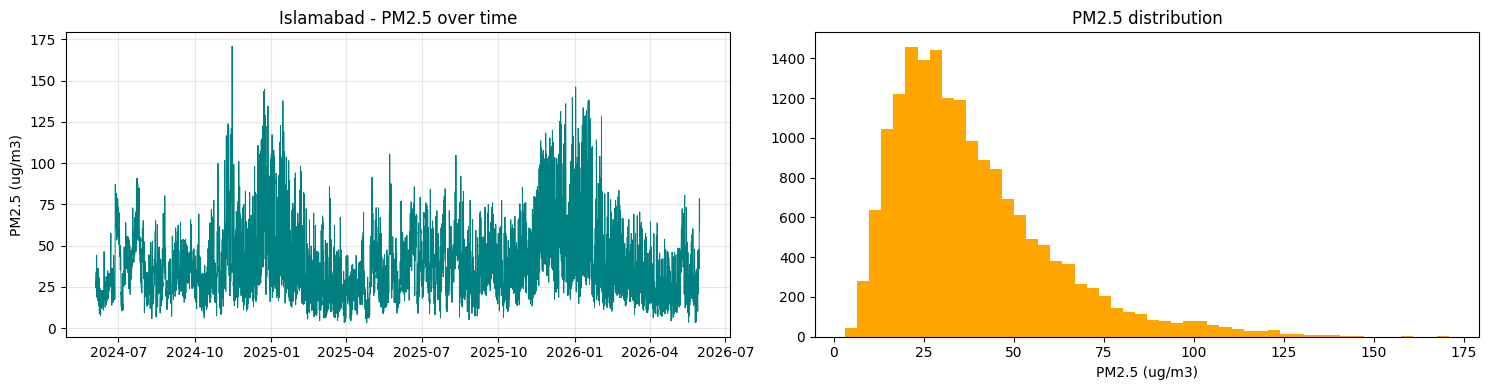

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))

ax[0].plot(df_clean["datetime"], df_clean["pm2_5"], color="teal", lw=0.7)
ax[0].set_title(f"{CITY_NAME} - PM2.5 over time")
ax[0].set_ylabel("PM2.5 (ug/m3)")
ax[0].grid(alpha=0.3)

ax[1].hist(df_clean["pm2_5"], bins=50, color="orange")
ax[1].set_title("PM2.5 distribution")
ax[1].set_xlabel("PM2.5 (ug/m3)")

plt.tight_layout()
plt.show()

## 5. Model Training

Three gradient-boosted and ensemble models are trained as multi-output regressors (one model predicting all three horizons). A chronological 80/20 split is used so the validation set always lies after the training set, as is appropriate for time-series data. The model with the highest average R-squared is selected.

In [10]:
TARGETS  = ["target_pm25_24h", "target_pm25_48h", "target_pm25_72h"]
EXCLUDE  = ["datetime", "aqi", "aqi_category"] + TARGETS
FEATURES = [c for c in df_clean.columns if c not in EXCLUDE]
print("Number of features:", len(FEATURES), "| Rows:", len(df_clean))

X = df_clean[FEATURES]
y = df_clean[TARGETS]

# Chronological split (no shuffling for time series)
split = int(len(X) * 0.8)
X_train, X_val = X.iloc[:split], X.iloc[split:]
y_train, y_val = y.iloc[:split], y.iloc[split:]


def build_models():
    models = {
        "RandomForest": RandomForestRegressor(
            n_estimators=200, max_depth=15, min_samples_leaf=3,
            max_features="sqrt", random_state=42, n_jobs=-1,
        )
    }
    try:
        from xgboost import XGBRegressor
        models["XGBoost"] = XGBRegressor(
            n_estimators=800, max_depth=8, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, tree_method="hist",
        )
    except ImportError:
        pass
    try:
        from lightgbm import LGBMRegressor
        models["LightGBM"] = LGBMRegressor(
            n_estimators=800, max_depth=10, num_leaves=31,
            learning_rate=0.05, subsample=0.8,
            random_state=42, n_jobs=-1, verbosity=-1,
        )
    except ImportError:
        pass
    return models


def evaluate_multioutput(model, X_eval, y_eval):
    preds = np.maximum(model.predict(X_eval), 0)  # AQI/PM2.5 cannot be negative
    metrics = {}
    for i, horizon in enumerate(["24h", "48h", "72h"]):
        metrics[horizon] = {
            "MAE":  round(mean_absolute_error(y_eval.iloc[:, i], preds[:, i]), 2),
            "RMSE": round(np.sqrt(mean_squared_error(y_eval.iloc[:, i], preds[:, i])), 2),
            "R2":   round(r2_score(y_eval.iloc[:, i], preds[:, i]), 3),
        }
    return metrics


results, fitted = {}, {}
for name, base_model in build_models().items():
    print(f"Training multi-output {name} ...")
    model = MultiOutputRegressor(base_model)
    model.fit(X_train, y_train)
    metrics = evaluate_multioutput(model, X_val, y_val)
    avg_r2 = np.mean([metrics[h]["R2"] for h in metrics])
    results[name] = (metrics, avg_r2)
    fitted[name] = model
    print("   " + " | ".join(f"{h} R2={metrics[h]['R2']}" for h in metrics)
          + f"  (average R2 {avg_r2:.3f})")

best_name = max(results, key=lambda k: results[k][1])
best_model = fitted[best_name]

print(f"\nBest model: {best_name} (average R2 {results[best_name][1]:.3f})")
print("\nDetailed metrics for the best model:")
for horizon, m in results[best_name][0].items():
    print(f"  {horizon}: MAE {m['MAE']} | RMSE {m['RMSE']} | R2 {m['R2']}")

Number of features: 44 | Rows: 17424
Training multi-output RandomForest ...
   24h R2=0.706 | 48h R2=0.622 | 72h R2=0.602  (average R2 0.643)
Training multi-output XGBoost ...
   24h R2=0.702 | 48h R2=0.609 | 72h R2=0.59  (average R2 0.634)
Training multi-output LightGBM ...
   24h R2=0.705 | 48h R2=0.618 | 72h R2=0.59  (average R2 0.638)

Best model: RandomForest (average R2 0.643)

Detailed metrics for the best model:
  24h: MAE 8.74 | RMSE 11.87 | R2 0.706
  48h: MAE 9.83 | RMSE 13.37 | R2 0.622
  72h: MAE 10.2 | RMSE 13.73 | R2 0.602


## 6. Actual vs Predicted

The plots below compare predicted PM2.5 against observed values on the validation set for each horizon.

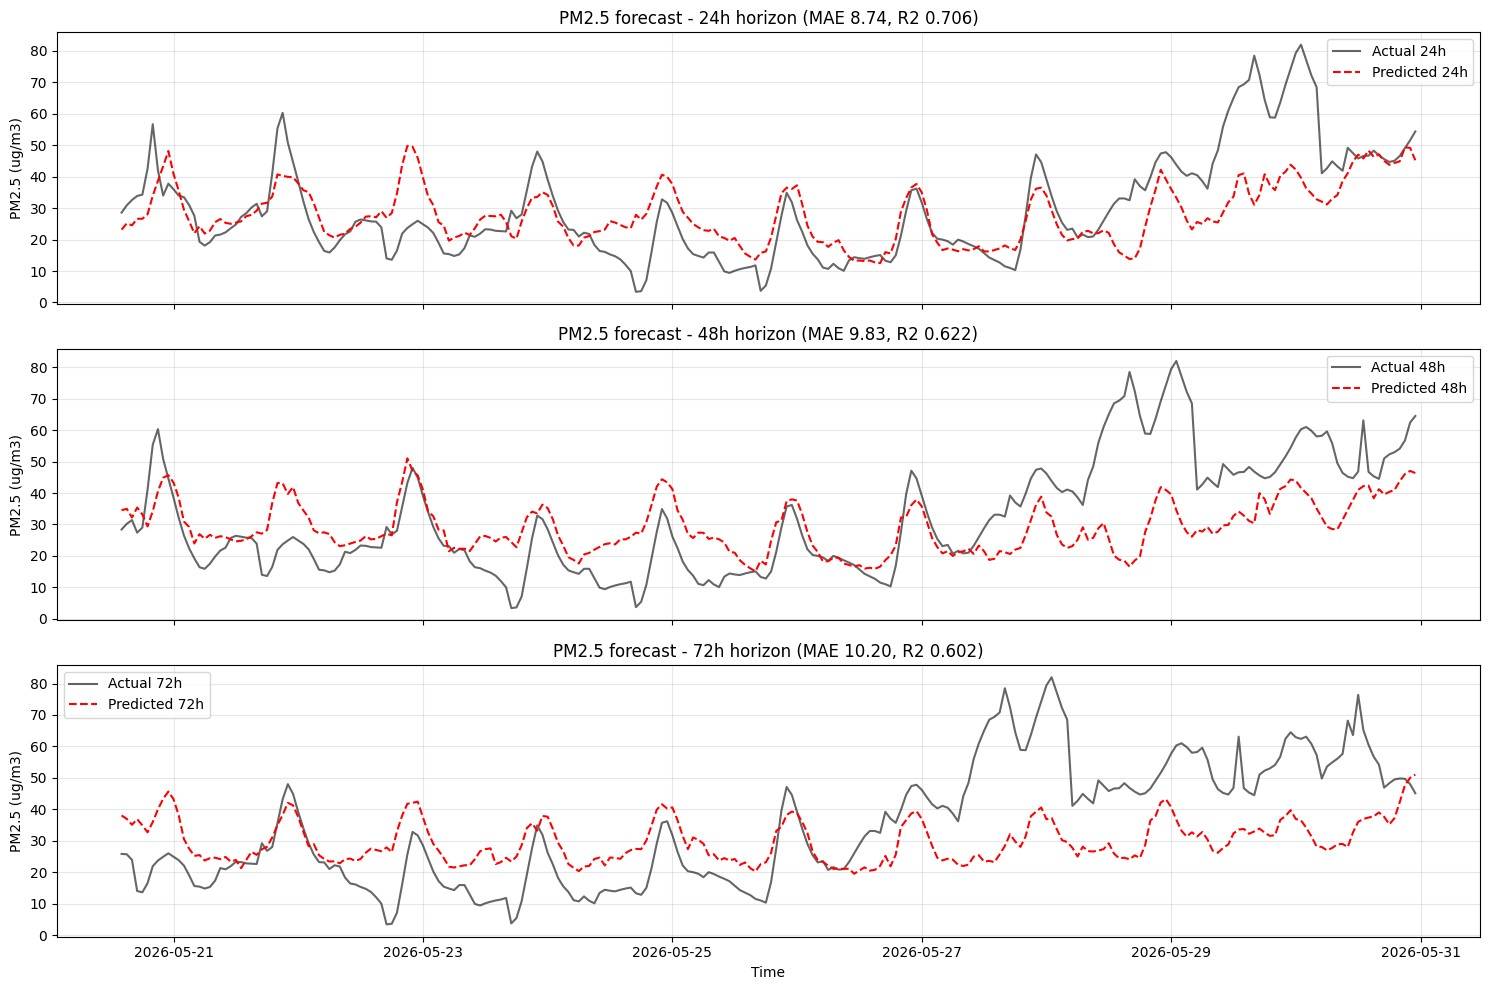

In [11]:
pred = np.maximum(best_model.predict(X_val), 0)
timestamps = df_clean["datetime"].iloc[split:].values
window = min(250, len(timestamps))

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
for i, horizon in enumerate(["24h", "48h", "72h"]):
    mae = mean_absolute_error(y_val.iloc[:, i], pred[:, i])
    r2  = r2_score(y_val.iloc[:, i], pred[:, i])
    axes[i].plot(timestamps[-window:], y_val.iloc[-window:, i].values,
                 color="black", alpha=0.6, label=f"Actual {horizon}")
    axes[i].plot(timestamps[-window:], pred[-window:, i],
                 color="red", linestyle="--", label=f"Predicted {horizon}")
    axes[i].set_title(f"PM2.5 forecast - {horizon} horizon (MAE {mae:.2f}, R2 {r2:.3f})")
    axes[i].set_ylabel("PM2.5 (ug/m3)")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## 7. Feature Importance (SHAP)

SHAP values are computed on the 24-hour estimator to show which features contribute most to the predictions. If SHAP is unavailable, the model's built-in feature importances are shown instead.

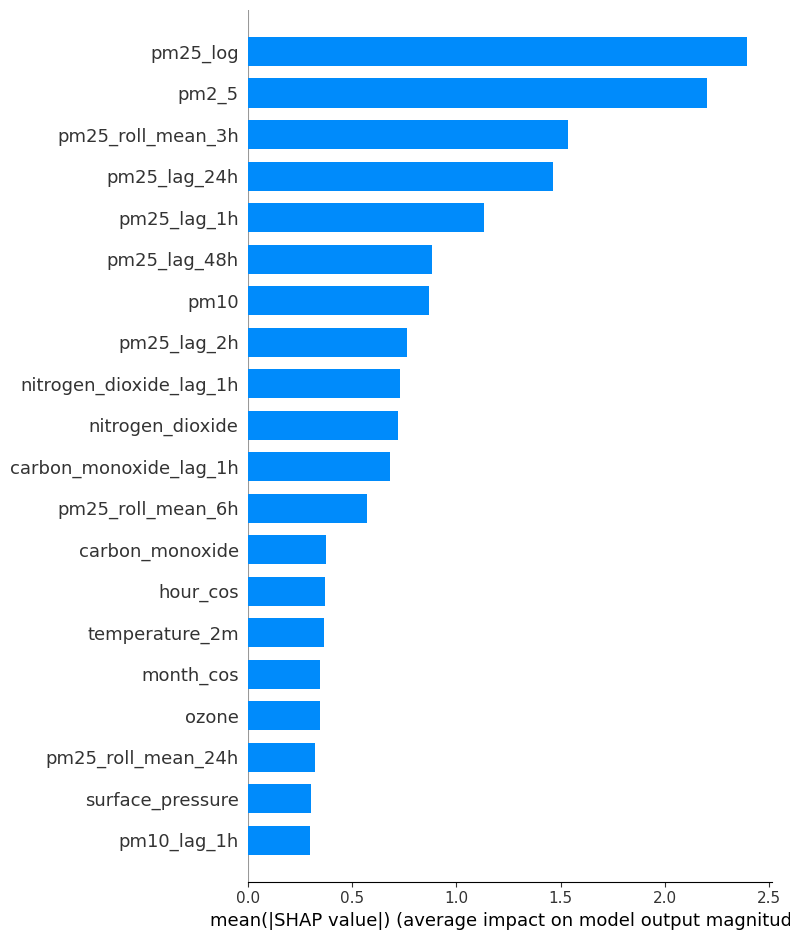

In [12]:
estimator_24h = best_model.estimators_[0]

try:
    import shap
    X_sample = X.sample(min(400, len(X)), random_state=42)
    shap_values = shap.TreeExplainer(estimator_24h).shap_values(X_sample)
    shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=20, show=True)
except Exception as error:
    print("SHAP unavailable, using built-in feature importances:", error)
    if hasattr(estimator_24h, "feature_importances_"):
        importances = pd.Series(estimator_24h.feature_importances_, index=FEATURES)
        importances.sort_values().tail(20).plot(kind="barh", figsize=(8, 7), color="darkorange")
        plt.title("Top features (24h horizon)")
        plt.tight_layout()
        plt.show()

## 8. Three-Day Forecast

The most recent feature row is passed to the trained model to forecast PM2.5 at each horizon, which is then converted to AQI.

In [13]:
latest_features = df_clean[FEATURES].iloc[[-1]]
pm_predictions = np.maximum(best_model.predict(latest_features)[0], 0)

forecast = pd.DataFrame({
    "Horizon": ["Tomorrow (24h)", "Day 2 (48h)", "Day 3 (72h)"],
    "Predicted_PM2.5": [round(p, 1) for p in pm_predictions],
    "Predicted_AQI": [calculate_aqi(p) for p in pm_predictions],
})
forecast["Category"] = forecast["Predicted_AQI"].apply(aqi_category)

print(f"{CITY_NAME} - three-day AQI forecast")
forecast

Islamabad - three-day AQI forecast


,Horizon,Predicted_PM2.5,Predicted_AQI,Category
0,Tomorrow (24h),45.2,125,Unhealthy for Sensitive Groups
1,Day 2 (48h),46.3,128,Unhealthy for Sensitive Groups
2,Day 3 (72h),51.0,139,Unhealthy for Sensitive Groups


## 9. Health Alerts

In [14]:
for _, row in forecast.iterrows():
    aqi = row["Predicted_AQI"]
    label = f"{row['Horizon']}: AQI {aqi} ({row['Category']})"
    if aqi > 200:
        print(f"ALERT  - {label}. Hazardous; avoid outdoor activity and wear a mask.")
    elif aqi > 150:
        print(f"WARNING- {label}. Unhealthy; limit time outdoors.")
    elif aqi > 100:
        print(f"CAUTION- {label}. Sensitive groups should take precautions.")
    else:
        print(f"OK     - {label}. Air quality is acceptable.")

CAUTION- Tomorrow (24h): AQI 125 (Unhealthy for Sensitive Groups). Sensitive groups should take precautions.
CAUTION- Day 2 (48h): AQI 128 (Unhealthy for Sensitive Groups). Sensitive groups should take precautions.
CAUTION- Day 3 (72h): AQI 139 (Unhealthy for Sensitive Groups). Sensitive groups should take precautions.


## 10. Save Model

The model is saved for use by the dashboard. LightGBM is preferred for deployment because it produces a much smaller file than Random Forest while achieving comparable accuracy, which keeps the artifact well under hosting size limits. If LightGBM was not trained, the best model is saved instead. Compression is enabled to reduce file size further.

In [15]:
# Prefer LightGBM for a compact deployment artifact; fall back to the best model.
if "LightGBM" in fitted:
    deploy_model, deploy_name = fitted["LightGBM"], "LightGBM"
else:
    deploy_model, deploy_name = best_model, best_name

joblib.dump(
    {"model": deploy_model, "features": FEATURES, "model_type": deploy_name},
    "aqi_models.pkl",
    compress=3,
)
print(f"Saved model '{deploy_name}' to aqi_models.pkl")
print("Saved training data to aqi_training_data.csv")

Saved model 'LightGBM' to aqi_models.pkl
Saved training data to aqi_training_data.csv


## Summary

The notebook produces two artifacts:

- `aqi_training_data.csv` - the engineered training dataset
- `aqi_models.pkl` - the trained multi-output model bundled with its feature list

These feed the Streamlit dashboard and the automated training pipeline. Note that Islamabad's pollution profile is more volatile than coastal cities, so forecast accuracy is expected to be lower than for smoother locations, particularly at the 72-hour horizon.
